# 05 — Output & Input Capacitor Sizing

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Size C_out for the ~160 Hz fan-commutation load ripple (the dominant constraint — the control loop is deliberately too slow to reject it), check TVS clamping on load-dump, then size C_in and check RMS-current/power ratings of all capacitors.

**Key results / decisions:** C_out = 4× 4.7 mF electrolytic + 9× 10 µF ceramic; C_in = 4× 47 µF electrolytic + 2× 10 µF ceramic (see Final Conclusion for part numbers).

**See also:** 06 (switching-frequency ripple), 07 (loop bandwidth this sizing assumes).

## Config: operating envelope and chosen bank

Max Fan Load Power: 33.60W


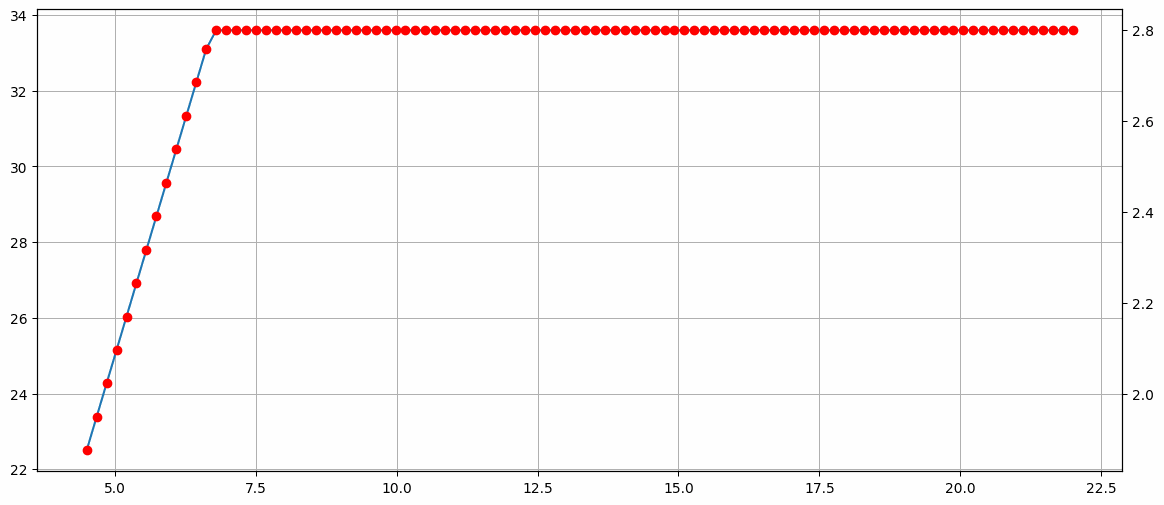

c_out r_esr: 18.34 mOhm


In [1]:
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

# Chosen output bank (defined here so every section below can use it)
c_out_chosen_nominal = 4.7e-3 * 4            # 4x 4.7 mF electrolytic
c_out_chosen_derated = c_out_chosen_nominal * 0.7   # 70% derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

# C_out

Cout Design
Given input current and power limitation, we want to have a steady input power.
Arctic P14 Pro PST is maximum 2500 rpm with 4-pole motor. Thus, at steady state max load, we expect a <160 Hz pulsing load. From measured data, we see it is approximately trapezoidal, and we can approximate as a 50% square wave.
This is much lower frequency and higher load ripple than the switching frequency. 

We are assuming dcdc converter control loop is designed to be "too slow" to react to 160 Hz pulsing load. At 0.5^(1/3) speed, there is half power according to fan laws https://en.wikipedia.org/wiki/Affinity_laws.
There can of course be higher current if it is stalled etc. Measured startup data approximately shows peak power at half speed. so we need to reject "fully" at half speed. at 1/4 speed, power ramps to about 1/2, and no longer need to reject since 200% spikes of 0.5 is still less than 100%. We might aim foro 1/4 speed as the corner frequency of the control loop.

A better method would be to set the control loop bandwidth low enough such that there is only a 10% response within 0.25 times max commutation frequency, assuming standard exponential 1st order response. Then, based on this control bandwidth, estimate the cap size needed to limit transient overshoot/undershoot.
For simplicity, use 1 / (4\*f_bw) for how much time for controller to respond. This is about 1.6 tau since 1 / (2\*pi\*f_bw) is 1 tau, settling 1-e^-(2*3.14/4) = 0.79

## Cap size from stability & transient response

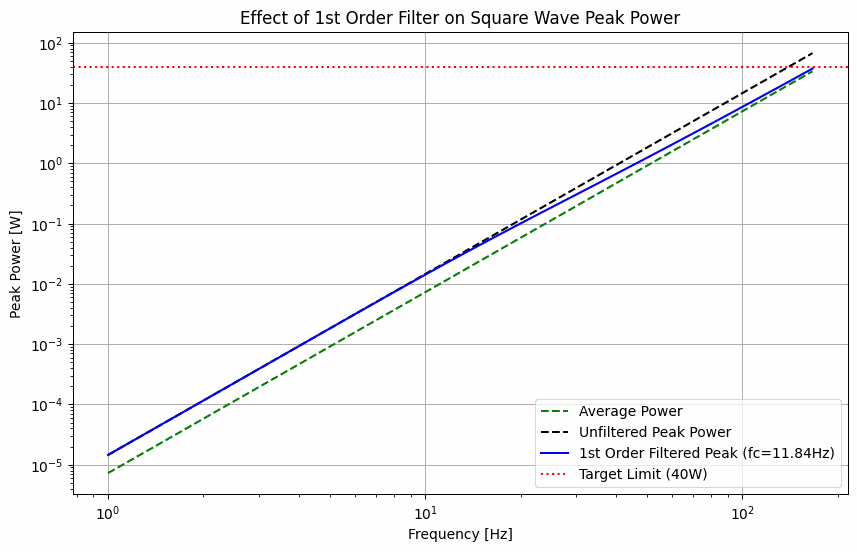

capacitance requried based on bandwidth and overshoot: 31.36 mF
on_period: 3.33 ms
capacitance requried based on bandwidth and commutation transient: 15.56 mF


In [2]:
max_commutation_freq = 2500/60*4
min_frequency_ratio_of_concern = 0.9 # assume we ramp very slowly, so max current doesnt happen until about 90% max speed, and given power is to the third power of speed, high speed is the worst case
i_dc_max = np.max(i_out_operating_points)
limit = 40.0 # Assume use 45 W usb-c supply with 10% efficiency loss through buck boost, so only have 40W peak available for fans
fc = 11.84 # Calculated cutoff frequency to hit 40W limit
freq = np.linspace(1, max_commutation_freq, 100)
i_dc_vs_speed = i_dc_max * (freq / max_commutation_freq)**3
p_peak_unfiltered = i_dc_vs_speed * 2 * v_out

# Filtered peak formula: P_peak / (1 + exp(-pi * fc / f))
p_peak_filtered = p_peak_unfiltered / (1 + np.exp(-np.pi * fc / freq))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(freq, i_dc_vs_speed * v_out, 'g--', label='Average Power')
plt.plot(freq, p_peak_unfiltered, 'k--', label='Unfiltered Peak Power')
plt.plot(freq, p_peak_filtered, 'b-', label=f'1st Order Filtered Peak (fc={fc}Hz)')
plt.axhline(y=limit, color='r', linestyle=':', label='Target Limit (40W)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Peak Power [W]')
plt.title('Effect of 1st Order Filter on Square Wave Peak Power')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

# $$\Delta V \approx \frac{\Delta I}{2 \pi f_c C}$$
voltage_tolerance_transient = 1.2 # allow 1.2V overshoot/undershoot when load suddenly stops/starts. 10% of nominal output
c_required = i_dc_max / 2 / np.pi / voltage_tolerance_transient / fc
print(f"capacitance requried based on bandwidth and overshoot: {c_required*1e3:.2f} mF")


# this is extremely large, so we will instead try using TVS diode to absorbe transient overshoot when fans turn off.
# thus, we only need capacitance to filter the ripple current to maintain a stable 12 V
voltage_tolerance_commutation_ripple = 0.6 # 0.6 V during the 160Hz commutation, so 11.7 to 12.3V
load_square_freq = max_commutation_freq * min_frequency_ratio_of_concern
on_period = 1/ load_square_freq / 2
print(f"on_period: {on_period * 1000:.2f} ms")

# $$\Delta V = \frac{I_{deficit} \cdot \Delta t}{C}$$

charge = i_dc_max * on_period
c_required = charge / voltage_tolerance_commutation_ripple
print(f"capacitance requried based on bandwidth and commutation transient: {c_required*1e3:.2f} mF")
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating


## TVS diode to absorb excess energy during load transient

Filter Time Constant (tau): 13.44 ms
Energy absorbed by TVS: 82.48 mJ


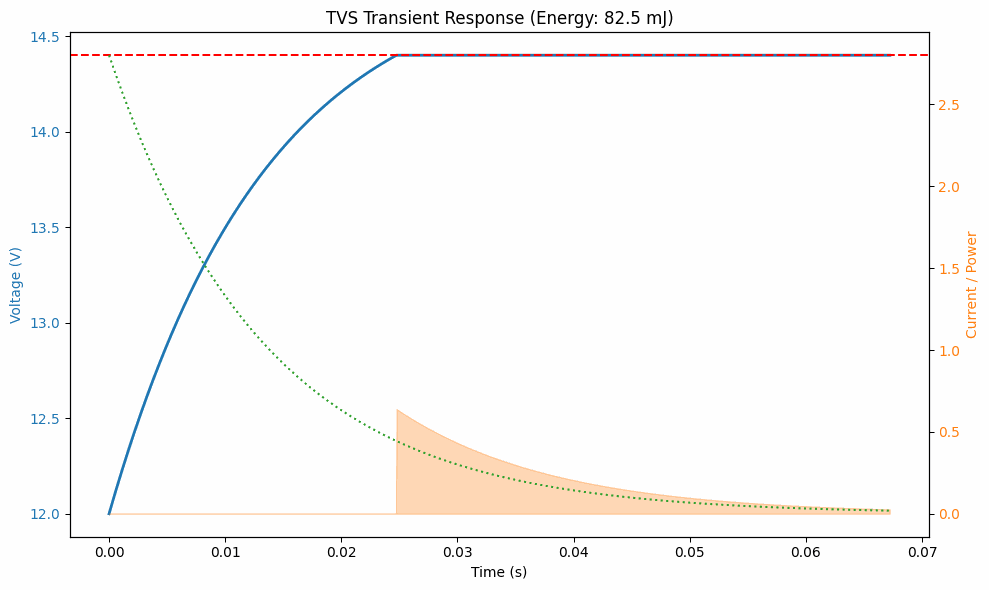

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs ---
c_total = c_out_chosen_derated      # Total capacitance (4x 4.7mF)
v_tvs_breakdown = 14.4 # SMBJ13A typical breakdown (V)

# --- Derived Values ---
tau = 1 / (2 * np.pi * fc)  # Filter time constant (~13.4 ms)
t = np.linspace(0, 5 * tau, 1000) # Simulation time

# 1. Source Current Response
# After the load steps to zero at t=0, the source current decays exponentially 
# because of the 1st-order filter logic.
i_source = i_dc_max * np.exp(-t / tau)

# 2. Voltage Rise Calculation (Numerical Integration)
# Voltage increases as the source current charges the capacitor
# dV = (I / C) * dt
v_out_time = np.zeros_like(t)
v_out_time[0] = v_out
tvs_power = np.zeros_like(t)

for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    
    # Calculate potential voltage increase
    dv = (i_source[i] / c_total) * dt
    new_v = v_out_time[i-1] + dv
    
    if new_v > v_tvs_breakdown:
        v_out_time[i] = v_tvs_breakdown
        # Current that doesn't go into cap must go through TVS
        # (Assuming the cap is 'full' relative to the clamping voltage)
        tvs_power[i] = i_source[i] * v_tvs_breakdown
    else:
        v_out_time[i] = new_v
        tvs_power[i] = 0

# 3. Energy Integration
tvs_energy_joules = np.trapezoid(tvs_power, t)

# --- Output Results ---
print(f"Filter Time Constant (tau): {tau*1e3:.2f} ms")
print(f"Energy absorbed by TVS: {tvs_energy_joules*1e3:.2f} mJ")

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Voltage (V)', color='tab:blue')
ax1.plot(t, v_out_time, color='tab:blue', linewidth=2, label='Output Voltage')
ax1.axhline(y=v_tvs_breakdown, color='r', linestyle='--', label='TVS Clamping Level')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Current / Power', color='tab:orange')
ax2.plot(t, i_source, color='tab:green', linestyle=':', label='Source Current (A)')
ax2.fill_between(t, tvs_power/10, color='tab:orange', alpha=0.3, label='TVS Power Dissipation (scaled)')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f'TVS Transient Response (Energy: {tvs_energy_joules*1e3:.1f} mJ)')
fig.tight_layout()
plt.show()

## Cap size from commutation-frequency output ripple

Max DC output current: 2.80 A
AC current amplitude: 2.80 A
Required capacitance: 8400.0 uF


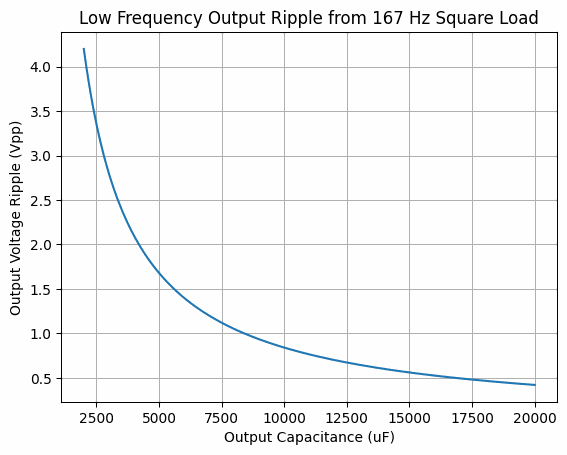

In [4]:
# --- CONFIGURATION ---
L = 47e-6          # Inductor Value from Buck_Boost_Initial_Calculations

load_square_freq = 2500/60*4
load_amplitude_factor = 1.0

i_dc_max = np.max(i_out_operating_points)

# AC amplitude
i_ac = i_dc_max * load_amplitude_factor

# Required capacitance for target ripple
goal_output_ripple_voltage = 1.0

c_required = i_ac / (2 * load_square_freq * goal_output_ripple_voltage)

print(f"Max DC output current: {i_dc_max:.2f} A")
print(f"AC current amplitude: {i_ac:.2f} A")
print(f"Required capacitance: {c_required*1e6:.1f} uF")


# RNL1E102MDS4
# 1000uf
# https://www.nichicon.co.jp/english/series_items/catalog_pdf/e-rnl.pdf
# https://www.digikey.com/en/products/detail/nichicon/RNL1E102MDS4/21317088

# https://www.digikey.com/en/products/detail/panasonic-electronic-components/EEU-FC1C472/266272
# MPN: EEU-FC1C472
# Digikey PN: P10263-ND
# 1 at $2.72, 10 at $1.46
# Ripple Current @ Low Frequency
# 2.559 A @ 120 Hz
# Ripple Current @ High Frequency
# 3.01 A @ 100 kHz
# load ripple of 2.8 A, so 2x of this capacitor is sufficient


# https://www.mouser.com/ProductDetail/Panasonic/ECA-1EHG472U?qs=0h1gzos03f1A4LfRGGZtVA%3D%3D


# if want 25v instead of 16V:
# https://www.digikey.com/en/products/detail/chemi-con/EKYB250ELL472MM25S/4843714
# https://www.digikey.com/en/products/detail/rubycon/25PK4700MEFC16X25/3564433

# Sweep capacitance values
c_out = np.linspace(2000e-6, 20000e-6, 200)

delta_v_pp = i_ac / (2 * load_square_freq * c_out)

plt.figure()
plt.plot(c_out*1e6, delta_v_pp)
plt.xlabel("Output Capacitance (uF)")
plt.ylabel("Output Voltage Ripple (Vpp)")
plt.title(f"Low Frequency Output Ripple from {round(load_square_freq)} Hz Square Load")
plt.grid(True)
plt.show()


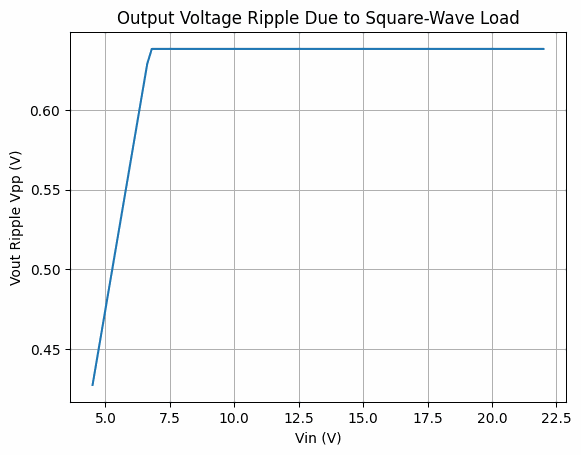

In [5]:
# AC amplitude
i_ac = i_out_operating_points * load_amplitude_factor

# Output ripple voltage (peak-to-peak)
delta_v_out_pp = i_ac / (2 * load_square_freq * c_out_chosen_derated)

# Optional: Plot vs Vin (ripple is independent of Vin in this simplified case)
plt.figure()
plt.plot(v_in, delta_v_out_pp * np.ones_like(v_in))
plt.xlabel("Vin (V)")
plt.ylabel("Vout Ripple Vpp (V)")
plt.title("Output Voltage Ripple Due to Square-Wave Load")
plt.grid(True)
plt.show()

## Output current ripple due to switching (boost mode)

1.3875630851960046


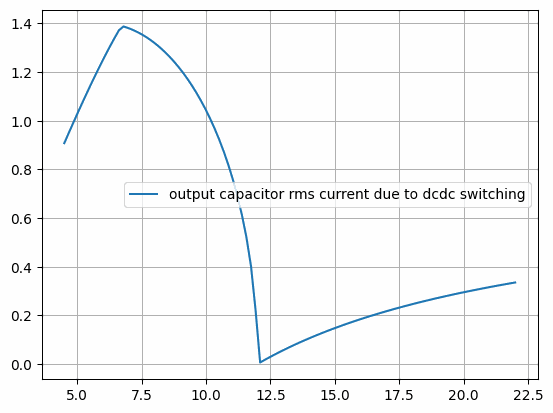

3.124953010110496


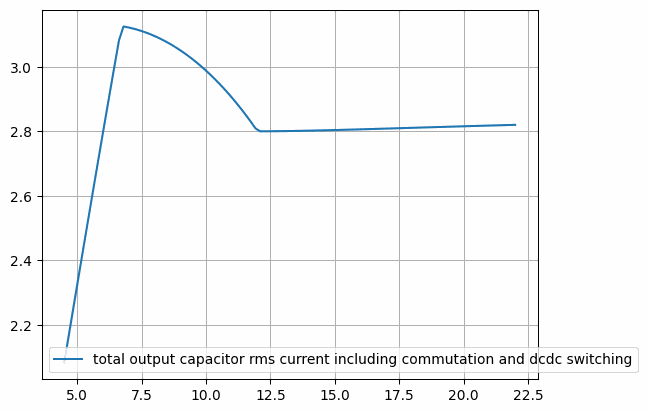

In [6]:
# Duty cycle (ideal CCM)
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Inductor ripple (valid for both modes if written carefully)
delta_i_l = np.where(
    v_in >= v_out,
    ((v_in - v_out) * D) / (L * f_sw),   # buck
    (v_in * D) / (L * f_sw)              # boost
)

# Buck: ripple-based
i_cout_buck = delta_i_l / np.sqrt(12)

# Boost: duty-based
i_cout_boost = i_out_operating_points * np.sqrt(D * (1 - D))

# Combine
i_cout_rms = np.where(
    v_in >= v_out,
    i_cout_buck,
    i_cout_boost
)

print(np.max(i_cout_rms))
plt.plot(v_in, i_cout_rms, label = "output capacitor rms current due to dcdc switching")
plt.grid()
plt.legend()
plt.show()

# output ripple of 1.4A at 100kHz is within limits of output capacitors
# We have 1.4A at 100kHz, and out at < 160Hz commutation
total_i_cout_rms = np.sqrt(i_out_operating_points**2 + i_cout_rms**2)
print(np.max(total_i_cout_rms))
plt.plot(v_in, total_i_cout_rms, label = "total output capacitor rms current including commutation and dcdc switching")
plt.legend()
plt.grid()

## Output voltage ripple due to switching

Worst case ripple: 0.21151734671477554


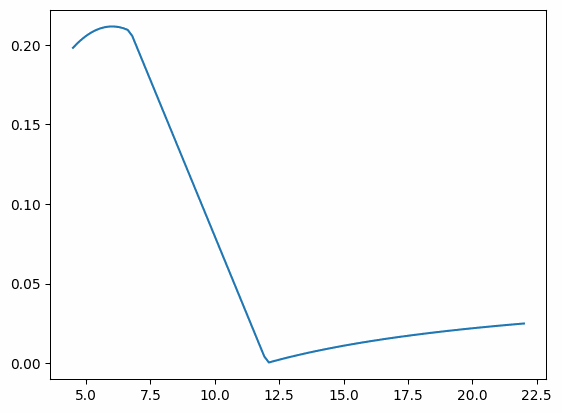

In [7]:
c_out_bulk = c_out_chosen_nominal

c_out_ceramic_dc_bias_derate = 0.3
num_c_out_ceramic = 9
c_out_ceramic = 22e-6 * num_c_out_ceramic * c_out_ceramic_dc_bias_derate # assume ceramic handles all 100kHz switching

# 10 uf $0.08  https://www.digikey.com/en/products/detail/taiyo-yuden/TMK316BJ106KL-T/930689
# https://www.farnell.com/datasheets/2081944.pdf

# 22uf $0.09 https://www.digikey.com/en/products/detail/taiyo-yuden/TMK316BBJ226ML-T/3660084
# https://mm.digikey.com/Volume0/opasdata/d220001/medias/docus/506/TMK316BBJ226ML-T_SS.pdf
# choose 22uF

c_out_dissipation_factor = 0.14 + 0.02 * 5
f_df = 120
r_esr_bulk = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_bulk)
r_esr_ceramic = .004 / num_c_out_ceramic # @ 100khz, 4 mOhm

# Duty cycle
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Inductor ripple
delta_i_l = np.where(
    v_in >= v_out,
    ((v_in - v_out) * D) / (L * f_sw),  # buck
    (v_in * D) / (L * f_sw)             # boost
)

# --- Capacitive ripple ---

delta_v_c = np.where(
    v_in >= v_out,
    delta_i_l / (8 * f_sw * c_out_ceramic),         # buck
    (i_out_operating_points * D) / (f_sw * c_out_ceramic)  # boost
)

# --- ESR ripple ---

delta_v_esr = np.where(
    v_in >= v_out,
    delta_i_l * r_esr_ceramic,                   # buck
    i_out_operating_points * r_esr_ceramic       # boost
)

# --- Total ripple (approx peak-to-peak sum) ---

delta_v_total = delta_v_c + delta_v_esr

print("Worst case ripple:", np.max(delta_v_total))
plt.plot(v_in, delta_v_total)

# switching voltage ripple is very small compared to ripple due to square wave load


## Output capacitor power check

Max Switching Loss in Bulk Cap: 0.006 W
Max Commutation Loss: 0.205 W


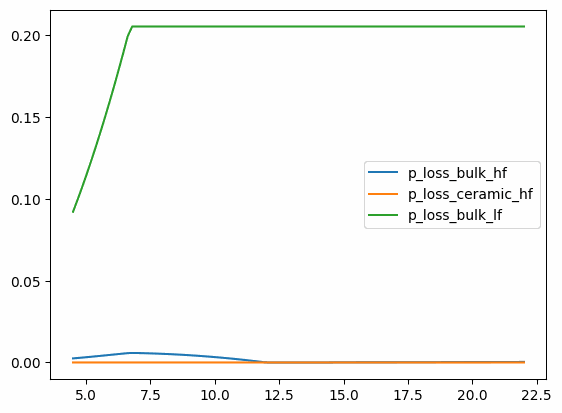

In [8]:
# Updated Datasheet Values
z_100khz_bulk_4700uf = 0.016  # From datasheet
z_100khz_bulk = z_100khz_bulk_4700uf / 4
r_esr_bulk_low_freq = 0.0262 # Your 120Hz calculation for commutation

# Current Divider at 100kHz
# Z_cer is dominated by its capacitive reactance at 100kHz
xc_ceramic = 1 / (2 * np.pi * f_sw * c_out_ceramic)
z_cer_100khz = np.sqrt(r_esr_ceramic**2 + xc_ceramic**2)

# Parallel current split
# i_sw_to_bulk: Current of the 100kHz ripple entering the large cap
i_sw_to_bulk = i_cout_rms * (z_cer_100khz / (z_cer_100khz + z_100khz_bulk))
i_sw_to_cer = i_cout_rms * (z_100khz_bulk / (z_cer_100khz + z_100khz_bulk))

# Power Loss (The "Real" Way)
# 1. High frequency loss in bulk cap (using 100kHz Z as proxy for ESR)
p_loss_bulk_hf = (i_sw_to_bulk**2) * z_100khz_bulk 

# 1b. High frequency loss in ceramic cap (ESR)
p_loss_ceramic_hf = (i_sw_to_cer**2) * r_esr_ceramic 

# 2. Low frequency loss in bulk cap (commutation)
p_loss_bulk_lf = (i_out_operating_points**2) * r_esr_bulk_low_freq

total_bulk_dissipation = p_loss_bulk_hf + p_loss_bulk_lf

print(f"Max Switching Loss in Bulk Cap: {np.max(p_loss_bulk_hf):.3f} W")
print(f"Max Commutation Loss: {np.max(p_loss_bulk_lf):.3f} W")
plt.plot(input_voltage_operating_points, p_loss_bulk_hf, label = "p_loss_bulk_hf")
plt.plot(input_voltage_operating_points, p_loss_ceramic_hf, label = "p_loss_ceramic_hf")
plt.plot(input_voltage_operating_points, p_loss_bulk_lf, label = "p_loss_bulk_lf")
plt.legend()

c_out r_esr_bulk: 16.93 mOhm
c_out r_esr_bulk: 18.34 mOhm
output capacitor power dissipation: 0.206


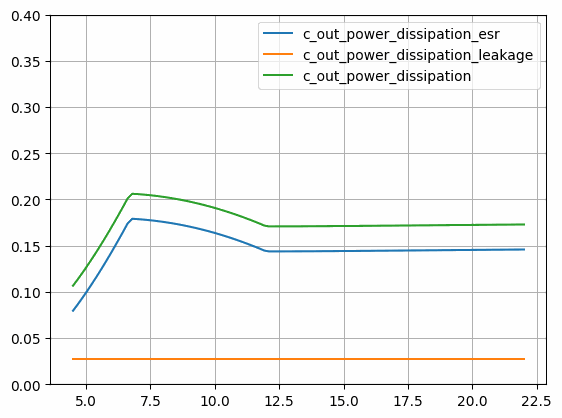

In [9]:
c_out_bulk = c_out_chosen_nominal
# 4700uF https://www.digikey.com/en/products/detail/chemi-con/EKYB250ELL472MM25S/4843714
c_out_dissipation_factor = 0.14 + 0.02 * 5
f_df = 120
r_esr_bulk = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_bulk)
leakage_current = max(0.01 * c_out_bulk * v_out, 3e-6)
print(f"c_out r_esr_bulk: {r_esr_bulk*1000:.2f} mOhm")

# https://www.digikey.com/en/products/detail/rubycon/25PK4700MEFC16X25/3564433
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr_bulk = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_bulk)
leakage_current = max(0.01 * c_out_bulk * v_out, 3e-6)
print(f"c_out r_esr_bulk: {r_esr_bulk*1000:.2f} mOhm")

c_out_power_dissipation_esr = total_i_cout_rms**2 * r_esr_bulk
c_out_power_dissipation_leakage = v_out * leakage_current
c_out_power_dissipation = c_out_power_dissipation_esr + c_out_power_dissipation_leakage
print(f"output capacitor power dissipation: {max(c_out_power_dissipation):.3f}")
plt.plot(input_voltage_operating_points, c_out_power_dissipation_esr, label = "c_out_power_dissipation_esr")
plt.plot([input_voltage_operating_points[0],input_voltage_operating_points[-1]], [c_out_power_dissipation_leakage,c_out_power_dissipation_leakage], label = "c_out_power_dissipation_leakage")
plt.plot(input_voltage_operating_points, c_out_power_dissipation, label = "c_out_power_dissipation")
plt.ylim([0,0.4])
plt.legend()
plt.grid()


# C_in

 Max Input Ripple: 1.39 A rms


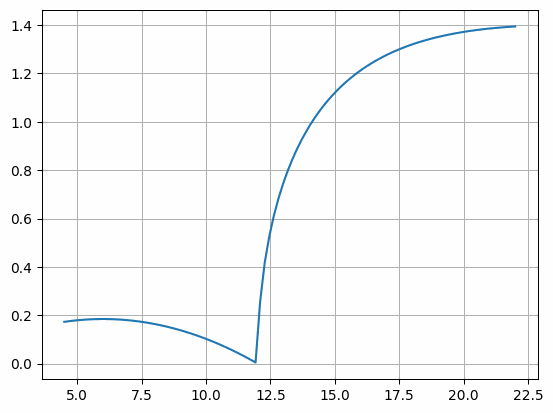

In [10]:
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Buck input cap RMS
i_cin_buck = i_out_operating_points * np.sqrt(D * (1 - D))

# Boost inductor ripple
delta_i_l = (v_in * D) / (L * f_sw)

i_cin_boost = delta_i_l / np.sqrt(12)

# Combine modes
i_cin_rms = np.where(
    v_in >= v_out,
    i_cin_buck,
    i_cin_boost
)

print(f" Max Input Ripple: {np.max(i_cin_rms):.2f} A rms")
plt.plot(v_in, i_cin_rms)
plt.grid()


In [11]:
i_rms = 1.39      # A
f_sw = 100e3      # Hz
delta_v_target = 0.5  # V

c_in_required = i_rms / (2 * np.pi * f_sw * delta_v_target)
print(f"Minimum input capacitance needed: {c_in_required*1e6:.1f} uF")

# https://www.digikey.com/en/products/detail/rubycon/35ZLJ47M5X11/3562956
# 47 uF aluminum electrolytic is cheap
# 450 mA ripple current at 100 kHz
# 0.4 Ohm impedance at 100 kHz
# Choose to use 4x 47 uF aluminum electrolytic
# 0.1 Ohm total parallel impedance so approximately 0.139 V ripple

Minimum input capacitance needed: 4.4 uF


# Final Conclusion

In [12]:
output_cap_bulk = "4x 4.7mF 25V EKYB250ELL472MM25S"
# https://www.digikey.com/en/products/detail/chemi-con/EKYB250ELL472MM25S/4843714
# update to lkmj2001e472mf, also 3A rating at 120hz +, and same diameter and lead spacing. lower impedance
# https://www.ymin.cn/lead-type-miniature-type-aluminum-electrolytic-capacitor-lkm-product/
output_cap_ceramic = "9x 10uF 25V TMK316BJ106KL-T" # X5R or X7R capacitor, size 0805 ideally for ease of manual soldering
# https://www.digikey.com/en/products/detail/taiyo-yuden/TMK316BJ106KL-T/930689
# update to cl31a106kbhnnne as it is a "basic" part at jlpcb saving $3 fee
input_cap = "4x 47uF 35V aluminum electrolytic 35ZLJ47M5X11" # https://www.digikey.com/en/products/detail/rubycon/35ZLJ47M5X11/3562956
input_cap_ceramic = "2x 10uF 35V ceramic" # for good measure. X5R or X7R capacitor, size 0805 ideally for ease of manual soldering
# https://www.digikey.com/en/products/detail/taiyo-yuden/GMK316BJ106KL-T/2217972"

# use for all 10uF, 35V, 1206 https://jlcpcb.com/partdetail/TaiyoYuden-GMK316AB7106KLTR/C454102

output_tvs_diode ="1x 14.4V TVS SMBJ13A" # https://www.digikey.com/en/products/detail/littelfuse-inc/SMBJ13A/285974
# update to SMB5352A. similar 5w long term power, and similar 10a 1ms peak pulse power.